# Kalman Filter: Moving Uncertainty Through Matrices

A robot rarely knows its state exactly. It predicts from a motion model, then corrects that prediction with noisy measurements. This notebook builds a linear Kalman filter from NumPy matrix operations and tracks a one-dimensional vehicle whose state contains position and velocity.


## State, motion, and measurement models

The state is $x=[p, v]^T$. A constant-velocity model advances it by one time step:

$$x_k^- = F x_{k-1}, \qquad F=\begin{bmatrix}1 & \Delta t\\0 & 1\end{bmatrix}.$$

The sensor observes position but not velocity directly:

$$z_k = Hx_k + \text{noise}, \qquad H=\begin{bmatrix}1 & 0\end{bmatrix}.$$

Here $F$ maps the state forward, while $H$ maps the state into measurement space.


## Predict and update uncertainty

The covariance $P$ describes uncertainty in the state. Prediction transports that uncertainty through the same motion model and adds process noise $Q$:

$$P_k^- = F P_{k-1} F^T + Q.$$

The innovation $y=z-Hx^-$ is the part of the measurement the prediction did not explain. Its covariance and the Kalman gain are

$$S=HP^-H^T+R, \qquad K=P^-H^TS^{-1}.$$

The gain balances trust: larger predicted uncertainty makes the filter respond more to the measurement; larger measurement noise $R$ makes it trust the prediction more.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from linalg_playground.kalman import predict, update


In [2]:
rng = np.random.default_rng(7)
dt = 1.0
num_steps = 100
times = np.arange(num_steps) * dt
true_velocity = 0.7
true_position = true_velocity * times
measurement_std = 2.0
measurements = true_position + rng.normal(scale=measurement_std, size=num_steps)
measurements[45:60] = np.nan  # Simulate a temporary sensor dropout.

F = np.array([[1.0, dt], [0.0, 1.0]])
H = np.array([[1.0, 0.0]])
acceleration_variance = 0.0001
Q = acceleration_variance * np.array([[dt**4 / 4, dt**3 / 2], [dt**3 / 2, dt**2]])
R = np.array([[measurement_std**2]])

state = np.array([0.0, 0.0])
covariance = np.diag([10.0, 10.0])


In [3]:
estimates = []
position_variances = []
gains = []

for measurement in measurements:
    state, covariance = predict(state, covariance, F, Q)
    if np.isfinite(measurement):
        state, covariance, gain, innovation = update(
            state, covariance, np.array([measurement]), H, R
        )
    else:
        gain = np.full((2, 1), np.nan)
    estimates.append(state.copy())
    position_variances.append(covariance[0, 0])
    gains.append(gain.copy())

estimates = np.asarray(estimates)
position_variances = np.asarray(position_variances)
gains = np.asarray(gains)


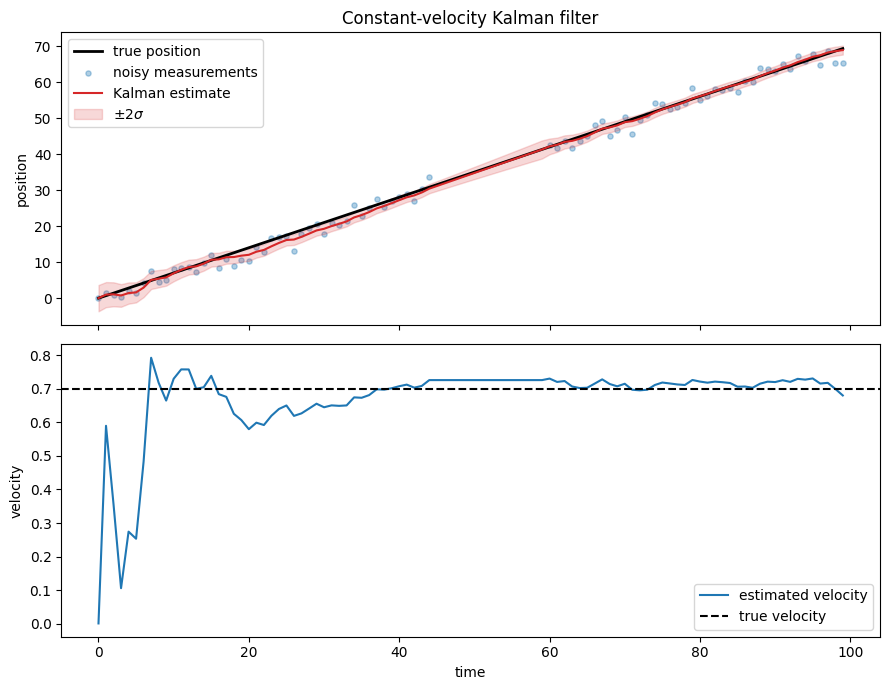

In [4]:
sigma = np.sqrt(position_variances)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1.plot(times, true_position, color="black", linewidth=2, label="true position")
ax1.scatter(times, measurements, s=14, alpha=0.35, label="noisy measurements")
ax1.plot(times, estimates[:, 0], color="tab:red", label="Kalman estimate")
ax1.fill_between(
    times, estimates[:, 0] - 2 * sigma, estimates[:, 0] + 2 * sigma,
    color="tab:red", alpha=0.18, label=r"$\pm 2\sigma$"
)
ax1.axvspan(times[45], times[59], color="0.8", alpha=0.35, label="sensor dropout")
ax1.set_ylabel("position")
ax1.set_title("Constant-velocity Kalman filter")
ax1.legend()

ax2.plot(times, estimates[:, 1], color="tab:blue", label="estimated velocity")
ax2.axhline(true_velocity, color="black", linestyle="--", label="true velocity")
ax2.set(xlabel="time", ylabel="velocity")
ax2.legend()
plt.show()


## Check what the filter accomplished

A useful estimate should beat the raw measurements, and every covariance matrix should remain symmetric and positive semidefinite.


In [5]:
valid = np.isfinite(measurements)
measurement_rmse = np.sqrt(np.mean((measurements[valid] - true_position[valid]) ** 2))
estimated_rmse = np.sqrt(np.mean((estimates[:, 0] - true_position) ** 2))

print(f"measurement RMSE: {measurement_rmse:.3f}")
print(f"Kalman estimate RMSE: {estimated_rmse:.3f}")
print("final state [position, velocity]:", estimates[-1])
print("uncertainty before/end/after dropout:", position_variances[44], position_variances[59], position_variances[60])

assert estimates.shape == (num_steps, 2)
assert estimated_rmse < measurement_rmse
assert position_variances[59] > position_variances[44]
assert position_variances[60] < position_variances[59]
assert np.allclose(covariance, covariance.T)
assert np.all(np.linalg.eigvalsh(covariance) >= -1e-12)


measurement RMSE: 1.765
Kalman estimate RMSE: 0.846
final state [position, velocity]: [68.87512399  0.67974231]
uncertainty before/end/after dropout: 0.4077286289953273 1.5722556702706665 1.1922321010967027


## Takeaway

> $F$ moves both the estimate and its uncertainty forward; the Kalman gain then uses relative uncertainty to decide how strongly a measurement should correct the prediction.

This linear version is the foundation of the EKF. In an EKF, nonlinear motion and measurement functions replace $F$ and $H$, and their Jacobians locally propagate uncertainty.
